<a href="https://colab.research.google.com/github/sgruyzcki/DiploDatos2026/blob/main/Introducci%C3%B3n-al-Aprendizaje-Autom%C3%A1tico/practico%202/IAA_2026_P2_Mariano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerias y modulos

In [103]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# TODO: Agregar las librerías que hagan falta
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold,  cross_val_score, cross_validate
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

## Carga de dataset

In [104]:
# Carga del dataset
loan_data = pd.read_csv("https://raw.githubusercontent.com/DiploDatos/IntroduccionAprendizajeAutomatico/master/data/loan_data.csv", comment="#")
loan_df = loan_data.copy()
loan_df.head(5)

,TARGET,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,0,4700,88026.0,115506.0,6.0,0.0,0.0,182.248332,0.0,27.0,29.209023
1,0,19300,39926.0,101208.0,4.0,0.0,0.0,140.051638,0.0,14.0,31.545694
2,0,5700,71556.0,79538.0,2.0,0.0,0.0,92.643085,0.0,15.0,41.210012
3,0,13000,44875.0,57713.0,0.0,1.0,0.0,184.990324,1.0,12.0,28.602076
4,0,19300,72752.0,106084.0,11.0,0.0,0.0,193.707100,1.0,13.0,30.686106


### Diccionario de variables:

- `TARGET`: La variable objetivo. Suele ser binaria ($0$ o $1$). Indica si el cliente incumplió con el pago (1) o si pagó puntualmente (0).

- `LOAN`: Monto del préstamo solicitado (en unidades monetarias).

- `MORTDUE`: Monto adeudado de la hipoteca existente (*Mortgage Due*).

- `VALUE`: Valor actual de la propiedad colocada como garantía.

- `YOJ`: Años en el trabajo actual (*Years on Job*).

- `DEROG`: Número de informes desfavorables o derogatorios (*Derogatory Reports*) en el historial crediticio (quiebras, demandas, etc.).

- `DELINQ`: Número de líneas de crédito morosas o delincuentes (*Delinquent Credit Lines*).

- `CLAGE`: Antigüedad de la línea de crédito más antigua en meses (*Age of Oldest Credit Line*).

- `NINQ`: Número de consultas de crédito recientes (*Number of Recent Credit Inquiries*). Esto mide qué tanto está buscando financiamiento el cliente.

- `CLNO`: Número de líneas de crédito activas que tiene el cliente (*Number of Credit Lines*).

- `DEBTINC`: Relación deuda-ingreso (*Debt-to-Income Ratio*). Expresado normalmente como un porcentaje (ej. 35.2 significa que el 35.2% de sus ingresos se van en pagar deudas).

## Limpieza general

In [105]:
# Estudio el dataset
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1854 entries, 0 to 1853
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TARGET   1854 non-null   int64  
 1   LOAN     1854 non-null   int64  
 2   MORTDUE  1854 non-null   float64
 3   VALUE    1854 non-null   float64
 4   YOJ      1854 non-null   float64
 5   DEROG    1854 non-null   float64
 6   DELINQ   1854 non-null   float64
 7   CLAGE    1854 non-null   float64
 8   NINQ     1854 non-null   float64
 9   CLNO     1854 non-null   float64
 10  DEBTINC  1854 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 159.5 KB


In [106]:
# Veo algunos valores de cada feature como ejemplo
loan_df.sample(5)

,TARGET,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
837,0,9700,63488.0,74374.0,5.0,0.0,0.0,106.589452,2.0,15.0,26.896013
214,0,12600,58247.0,72189.0,30.0,0.0,3.0,198.243176,0.0,23.0,35.794260
638,0,28200,61038.0,87534.0,8.0,0.0,0.0,137.487819,3.0,30.0,39.360019
800,0,11100,67366.0,102936.0,9.0,0.0,0.0,213.281496,0.0,20.0,19.078651
778,0,27600,64818.0,91915.0,16.0,0.0,0.0,99.604608,0.0,17.0,32.461144


In [107]:
# Sabiendo que son numericas, veo la descripcion del dataset
loan_data.describe()

,TARGET,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000
mean,0.166667,19111.758360,76316.051780,107321.088457,8.900216,0.187702,0.319849,180.300783,1.128910,21.857066,34.573408
std,0.372779,11000.345961,46227.026585,56039.685066,7.552677,0.704882,0.928452,84.838308,1.664555,9.510840,9.308794
min,0.000000,1700.000000,5627.000000,21144.000000,0.000000,0.000000,0.000000,0.486711,0.000000,0.000000,0.838118
25%,0.000000,12000.000000,48984.750000,70787.250000,3.000000,0.000000,0.000000,116.970718,0.000000,16.000000,29.427210
50%,0.000000,17000.000000,67201.000000,94198.000000,7.000000,0.000000,0.000000,174.967815,1.000000,21.000000,35.363407
75%,0.000000,23900.000000,93731.500000,122976.250000,13.000000,0.000000,0.000000,232.261800,2.000000,27.000000,39.357987
max,1.000000,89800.000000,399412.000000,512650.000000,41.000000,10.000000,10.000000,1168.233561,13.000000,65.000000,144.189001


Se observan variables con valores enteros cargadas como reales. Se hace esta corrección de tipos. No hay eliminación de duplicados ni tratamiento de nulos por hacer.

In [108]:
# Convertir YOJ,	DEROG,	DELINQ, CLNO y NINQ a features enteros
loan_df['LOAN'] = loan_df['LOAN'].astype(float)
loan_df['YOJ'] = loan_df['YOJ'].astype(int)
loan_df['DEROG'] = loan_df['DEROG'].astype(int)
loan_df['DELINQ'] = loan_df['DELINQ'].astype(int)
loan_df['CLNO'] = loan_df['CLNO'].astype(int)
loan_df['NINQ'] = loan_df['NINQ'].astype(int)
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1854 entries, 0 to 1853
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TARGET   1854 non-null   int64  
 1   LOAN     1854 non-null   float64
 2   MORTDUE  1854 non-null   float64
 3   VALUE    1854 non-null   float64
 4   YOJ      1854 non-null   int64  
 5   DEROG    1854 non-null   int64  
 6   DELINQ   1854 non-null   int64  
 7   CLAGE    1854 non-null   float64
 8   NINQ     1854 non-null   int64  
 9   CLNO     1854 non-null   int64  
 10  DEBTINC  1854 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 159.5 KB


## Distribucion y correlacion

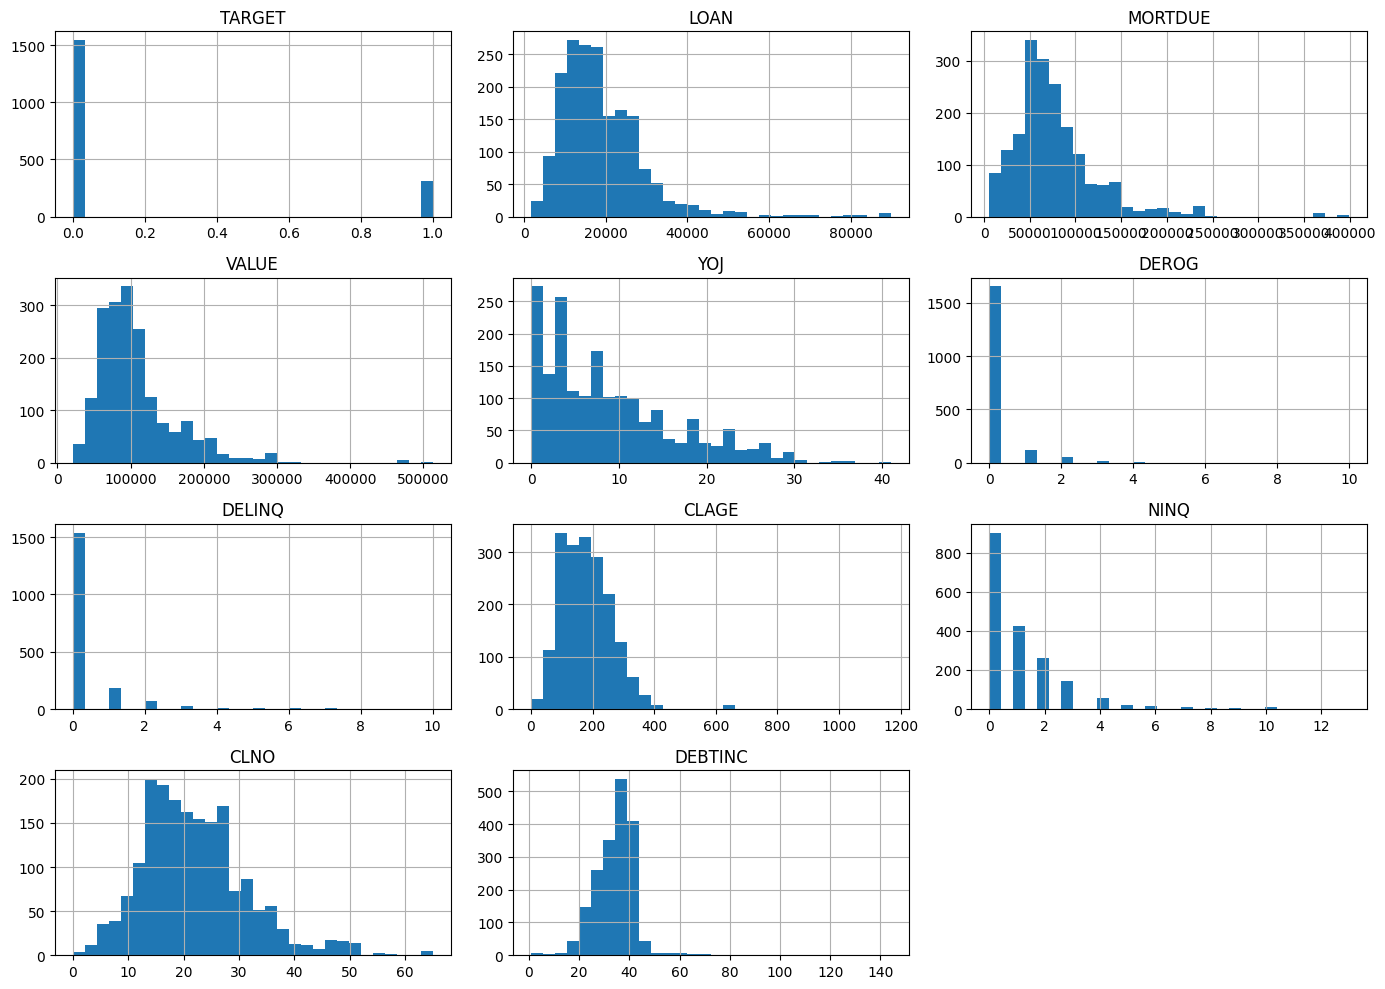

In [109]:
# Distribución de las variables
loan_df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

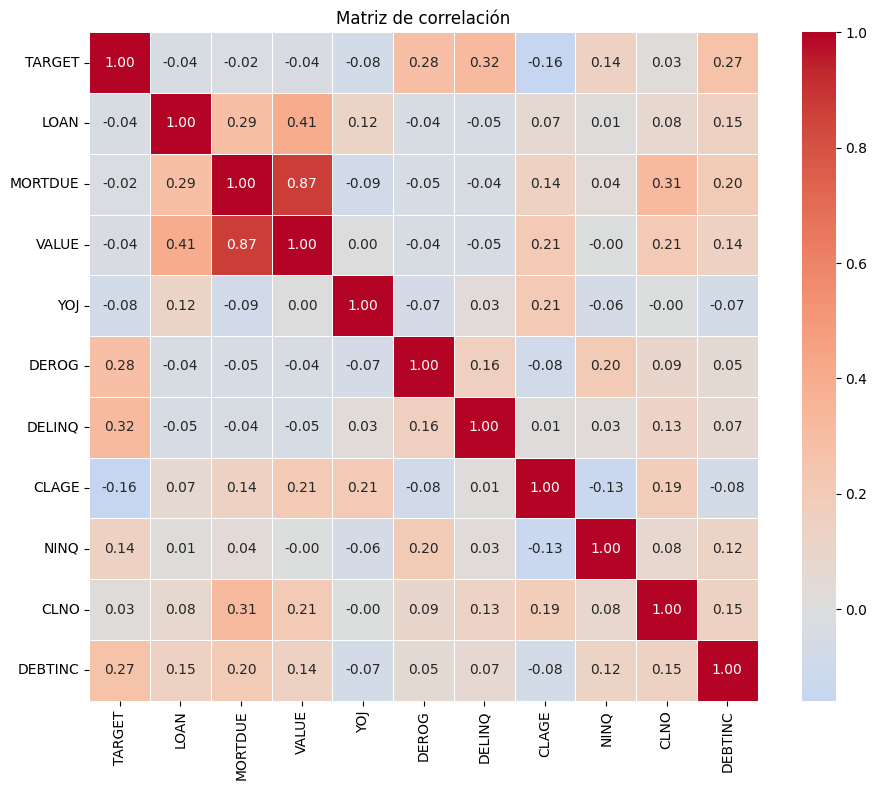

In [110]:
# Matriz de correlacion entre variables
corr = loan_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

### Correlación entre features
Se observa una fuerte correclación entre `MORTDUE` y `VALUE`. Esto indica una posible dependencia entre el monto adeudado de la hipoteca existente y el valor actual de la propiedad colocada como garantía.

Otra correlación de interés es entre `VALUE` y `LOAN`.

### Features significativos para el target
Por otro lado, las variables que mayor indicencia tienen en el `TARGET` son las siguientes:

- `DELINQ` ($0.32$): El historial de incumplimientos de pagos es lo que más condiciona el prestamo.
- `DEROG` ($0.28$): El número de informes desfavorables en el historial crediticio también es un factor determinante.
- `DEBTINC` ($0.27$): El porcentaje de los ingresos destinados a pagar la deuda se considera a la par que el punto anterior.
- `CLAGE` ($-0.16$): A mayor antiguedad de la linea de credito mas vieja, menos probable es obtener el credito.
- `NINQ` ($0.14$): Consultar con insistencia parace aumentar las probabilidades de obtener el credito.

Si bien no se observa una correlación significativa, esperaría que el valor de la propiedad puesta en garantía aumentase la posibilidad de obtener el crédito.



In [111]:
# Estudio de desbalance de clases
loan_df['TARGET'].value_counts()

,count
TARGET,
0,1545
1,309


In [112]:
loan_df["TARGET"].value_counts(normalize=True)

,proportion
TARGET,
0,0.833333
1,0.166667


Con lo anterior, vemos que los clientes que pagaron en tiempo y forma representan el 83.33% de los casos considerados en el dataset.

Este desbalance de clases puede generar problemas posteriormente, por lo que es necesario preservar esta distribucion a la hora de dividir los subconjuntos de testeo, validación y entrenamiento

## Division de dataset: Train, Val y Test

In [113]:
# División entre instancias y etiquetas
X, y = loan_df.iloc[:, 1:], loan_df.TARGET

# Reservo un 20% del dataset para test
X_aux, X_test, y_aux, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

# Del 80% restante, reservo el 20% para validacion
X_train, X_val, y_train, y_val = train_test_split(X_aux, y_aux, test_size=0.2, stratify=y_aux, random_state=0)

In [114]:
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_val:", X_val.shape)
print("Tamaño de X_test:", X_test.shape)

Tamaño de X_train: (1186, 10)
Tamaño de X_val: (297, 10)
Tamaño de X_test: (371, 10)


# Ejercicio 2: Predicción con modelos lineales

En esta parte vamos a usar un clasificador lineal entrenado mediante descenso de gradiente estocástico.

Antes de evaluar resultados, respondamos:

1. ¿Qué significa que sea un modelo lineal?

Rta: Significa que modela relaciones directas e interpretables entre variables. Tiene máxima interpretabilidad y asume relación lineal entre variables $y = w + w_ix$

2. ¿Qué función de pérdida estamos usando?

Rta: El SGDClassifier usa por default SVM lineal. La función de costo que minimiza en general un modelo lineal es MSE.

3. ¿Qué hiperparámetros aparecen en la documentación?

Rta: Los hiperparámetros principales son:
- loss: función de pérdida.
- penalty: término de penalización.
- alpha: constante que multiplica el término de regularización. Cuanto mayor sea su valor, más fuerte será la regularización.
- max_iter: número máximo de pasadas sobre los datos de entrenamiento.
- tol: criterio de parada.
- learning_rate: evolución de la tasa de aprendizaje
- eta0: tasa de aprendizaje inicial
- class_weight: asigna pesos a las clases

4. ¿Qué valores toma el modelo por defecto?

Rta: La configuración por default de la función es:
```python
SGDClassifier(loss='hinge', *,
              penalty='l2',
              alpha=0.0001,
              l1_ratio=0.15,
              fit_intercept=True,
              max_iter=1000,
              tol=0.001,
              shuffle=True,
              verbose=0,
              epsilon=0.1,
              n_jobs=None,
              random_state=None,
              learning_rate='optimal',
              eta0=0.01,
              power_t=0.5,
              early_stopping=False,
              validation_fraction=0.1,
              n_iter_no_change=5,
              class_weight=None,
              warm_start=False,
              average=False)
```

5. ¿Por qué la tasa de aprendizaje y la regularización pueden afectar el resultado?

Rta: Como vimos en el teórico, la elección de la tasa de aprendizaje puede determinar si el algoritmo converge, oscila o no llega. La regularización ayuda a disminuir el costo computacional del algoritmo. Con una regularización fuerte los coeficientes son pequeños y estables: el modelo captura la tendencia real sin memorizar el ruido.

In [115]:
model = SGDClassifier(random_state=42)
model.fit(X_train, y_train)

SGDClassifier(random_state=42)

In [116]:
y_train_predict = model.predict(X_train)
y_val_predict = model.predict(X_val)

In [117]:
# Evaluacion de metricas: Train set
print('Training metrics')
print('Accuracy :', accuracy_score(y_train, y_train_predict))
print('Precisiom:', precision_score(y_train, y_train_predict))
print('Recall   :',recall_score(y_train, y_train_predict))
print('F1-score :',f1_score(y_train, y_train_predict))

Training metrics
Accuracy : 0.8313659359190556
Precisiom: 0.375
Recall   : 0.015151515151515152
F1-score : 0.02912621359223301


In [118]:
# Muestro metricas usando classification_report
target_names = ['class 0', 'class 1']
print(classification_report(y_train, y_train_predict, target_names=target_names))


              precision    recall  f1-score   support

     class 0       0.83      0.99      0.91       988
     class 1       0.38      0.02      0.03       198

    accuracy                           0.83      1186
   macro avg       0.60      0.51      0.47      1186
weighted avg       0.76      0.83      0.76      1186



Matriz de Confusión (Train):


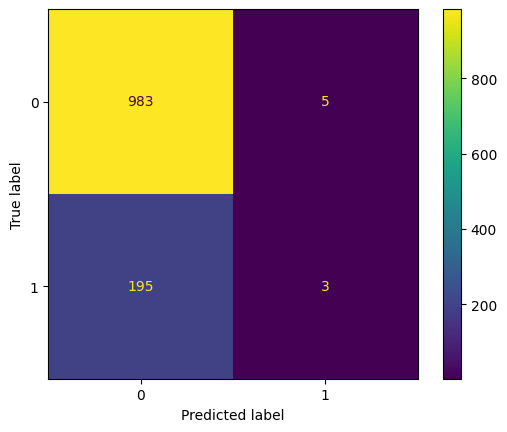

In [119]:
# Matriz de confusion: Train set
print("Matriz de Confusión (Train):")
ConfusionMatrixDisplay.from_predictions(y_train, y_train_predict)

### Interpretación del report Train

Clase 0:
- 83% de predicciones correctas. De todo lo que el modelo predijo como Clase 0, el 83% realmente lo era.
- Identifica el 99% de casos reales. El modelo es muy bueno para encontrar la Clase 0.
- Desempeño general bueno.

Clase 1:
- 38% de predicciones correctas. De lo que el modelo se animó a decir que era Clase 1, solo el 38% acertó.
- Identifica el 2% de casos reales. El modelo es prácticamente ciego a la Clase 1.
- Desempeño general malo.

El modelo clasifica bien 8.3 de cada 10 casos.

Tiene un Accuracy alto (83%) pero es un desastre con la Clase 1 porque el dataset está fuertemente desbalanceado: predice Clase 0 a casi todo. Como casi todo es Clase 0, el Accuracy da alto, pero el modelo en realidad no está aprendiendo a distinguir la Clase 1.

In [120]:
# Evaluacion de metricas: Validation set
print('Validation metrics')
print('Accuracy :', accuracy_score(y_val, y_val_predict))
print('Precisiom:', precision_score(y_val, y_val_predict))
print('Recall   :',recall_score(y_val, y_val_predict))
print('F1-score :',f1_score(y_val, y_val_predict))

Validation metrics
Accuracy : 0.8282828282828283
Precisiom: 0.0
Recall   : 0.0
F1-score : 0.0


In [121]:
print(classification_report(y_val, y_val_predict, target_names=target_names))

              precision    recall  f1-score   support

     class 0       0.83      0.99      0.91       248
     class 1       0.00      0.00      0.00        49

    accuracy                           0.83       297
   macro avg       0.42      0.50      0.45       297
weighted avg       0.70      0.83      0.76       297



Matriz de Confusión (Validation):


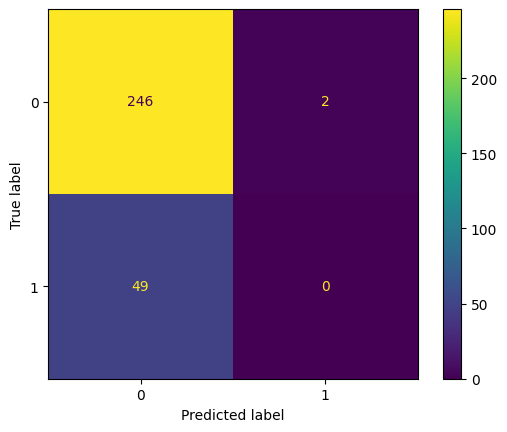

In [122]:
# Matriz de confusion: Validation set
print("Matriz de Confusión (Validation):")
ConfusionMatrixDisplay.from_predictions(y_val, y_val_predict)

### Interpretación del report Val

Clase 0:
- 83% de predicciones correctas.
- Identifica el 99% de casos reales.
- Desempeño general bueno.

Clase 1:
- 0% de predicciones correctas.
- Identifica el 0% de casos reales.
- Desempeño general malo.

El modelo clasifica bien 8.3 de cada 10 casos.


# Búsqueda de hiperparámetros con validación cruzada

Ahora no queremos quedarnos con una sola configuración del modelo.

Vamos a probar varias combinaciones de hiperparámetros y evaluarlas mediante validación cruzada.

Cuando analicemos los resultados de `GridSearchCV`, no miremos solamente el mejor score. También observemos:

1. `best_params_`: mejor combinación de hiperparámetros.
2. `best_score_`: mejor desempeño promedio en validación cruzada.
3. `mean_test_score`: media del score en validación.
4. `std_test_score`: variabilidad entre folds.
5. `mean_train_score`: desempeño promedio en entrenamiento, si está disponible.

Una configuración con media alta y desviación estándar baja suele ser más estable que una configuración con media alta pero gran variabilidad.


### Ejercicio 2.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del SGDClassifier. Como mínimo, probar diferentes funciones de loss, tasas de entrenamiento y tasas de regularización.

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [123]:
# División entre instancias y etiquetas
X, y = loan_df.iloc[:, 1:], loan_df.TARGET

# Reservo un 20% del dataset para test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

No tocar la casilla de abajo

In [124]:
model = SGDClassifier(random_state=42, class_weight='balanced')
param_grid = {
    'loss': ['hinge', 'log_loss', 'perceptron', 'modified_huber'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'eta0': [0.01, 0.1]
}

# Definir la estrategia Stratified k-fold cross-validation
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Ejecucion de busqueda de hiperparametros
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=stratified_kfold,
    scoring=[
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro"
    ],
    refit="f1_macro",
    return_train_score=True,
    n_jobs=-1
)

# Ajuste/exploracion via CV
grid_search.fit(X_train, y_train)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SGDClassifier(class_weight='balanced', random_state=42),
             n_jobs=-1,
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1],
                         'eta0': [0.01, 0.1],
                         'learning_rate': ['constant', 'optimal', 'invscaling',
                                           'adaptive'],
                         'loss': ['hinge', 'log_loss', 'perceptron',
                                  'modified_huber']},
             refit='f1_macro', return_train_score=True,
             scoring=['accuracy', 'precision_macro', 'recall_macro',
                      'f1_macro'])

In [125]:
# Impresión de mejores valores directos
print(f"Mejor combinación de hiperparámetros (best_params_): {grid_search.best_params_}")
print(f"Mejor score promedio en CV (best_score_): {grid_search.best_score_:.4f}\n")

Mejor combinación de hiperparámetros (best_params_): {'alpha': 0.001, 'eta0': 0.1, 'learning_rate': 'adaptive', 'loss': 'log_loss'}
Mejor score promedio en CV (best_score_): 0.5502



In [126]:
# Convertir todo el diccionario de resultados a DataFrame
df_resultados = pd.DataFrame(grid_search.cv_results_)

# Calcular la VARIANZA a partir de la desviación estándar (std**2)
df_resultados['variance_test_accuracy'] = df_resultados['std_test_accuracy']**2

# Definir las columnas básicas de parámetros y resumen que ya teníamos
columnas_base = [
    'param_loss',
    'param_alpha',
    'param_learning_rate',
    'param_eta0',
    'mean_train_f1_macro',     # Desempeño promedio en entrenamiento
    'mean_test_f1_macro',      # Desempeño promedio en validación (Test de CV)
    'std_test_f1_macro',       # Variabilidad entre folds para F1
    'mean_test_accuracy',      # Exactitud Promedio
    'variance_test_accuracy'   # Varianza de la Exactitud
]

tabla_detallada = df_resultados[columnas_base].sort_values(
    by='mean_test_f1_macro',
    ascending=False
)

tabla_detallada.columns = [
    'Función de Loss', 'Alpha (Reg.)', 'Learning Rate', 'Eta0 (LR Inicial)',
    'F1 Train Promedio', 'F1 Validación Promedio', 'Std F1 Validación',
    'Accuracy Promedio', 'Varianza Accuracy'
]

# Mostramos el Top 5 de combinaciones
tabla_detallada.head(5)

,Función de Loss,Alpha (Reg.),Learning Rate,Eta0 (LR Inicial),F1 Train Promedio,F1 Validación Promedio,Std F1 Validación,Accuracy Promedio,Varianza Accuracy
61,log_loss,0.0010,adaptive,0.1,0.554108,0.550247,0.039527,0.672946,0.001184
63,modified_huber,0.0010,adaptive,0.1,0.549304,0.547113,0.034963,0.664853,0.000920
30,perceptron,0.0001,adaptive,0.1,0.538840,0.541731,0.037938,0.655419,0.001588
28,hinge,0.0001,adaptive,0.1,0.538840,0.541731,0.037938,0.655419,0.001588
31,modified_huber,0.0001,adaptive,0.1,0.539331,0.536150,0.040025,0.647286,0.002410


In [127]:
# Como gridsearch ya tiene seleccionado el mejor modelo, evaluo los conjuntos de
# entrenamiento y validacion sobre gridsearch directamente
model = grid_search.best_estimator_

y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)

In [128]:
# Evaluacion de metricas: Train set
print('Best Model Training metrics\n')
print(f'Accuracy : {accuracy_score(y_train, y_train_predict):.4f}')
print(f'Precisiom: {precision_score(y_train, y_train_predict):.4f}')
print(f'Recall   : {recall_score(y_train, y_train_predict):.4f}')
print(f'F1-score : {f1_score(y_train, y_train_predict):.4f}\n')

# Muestro metricas usando classification_report
target_names = ['class 0', 'class 1']
print(classification_report(y_train, y_train_predict, target_names=target_names))


Best Model Training metrics

Accuracy : 0.6460
Precisiom: 0.2306
Recall   : 0.4818
F1-score : 0.3119

              precision    recall  f1-score   support

     class 0       0.87      0.68      0.76      1236
     class 1       0.23      0.48      0.31       247

    accuracy                           0.65      1483
   macro avg       0.55      0.58      0.54      1483
weighted avg       0.76      0.65      0.69      1483



Matriz de Confusión (Train):


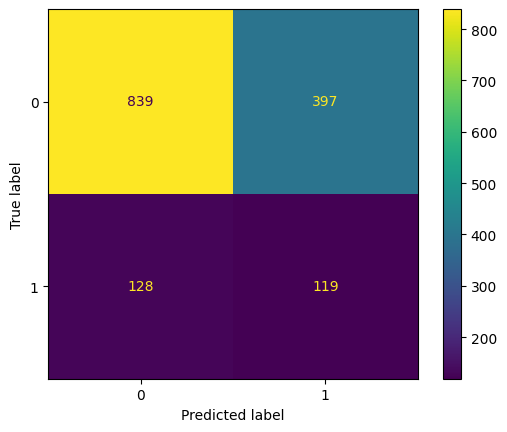

In [129]:
# Matriz de confusion: Train set
print("Matriz de Confusión (Train):")
ConfusionMatrixDisplay.from_predictions(y_train, y_train_predict)

In [130]:
# Evaluacion de metricas: Test set
print('Best Model Test metrics\n')
print(f'Accuracy : {accuracy_score(y_test, y_test_predict):.4f}')
print(f'Precisiom: {precision_score(y_test, y_test_predict):.4f}')
print(f'Recall   : {recall_score(y_test, y_test_predict):.4f}')
print(f'F1-score : {f1_score(y_test, y_test_predict):.4f}\n')

# Muestro metricas usando classification_report
target_names = ['class 0', 'class 1']
print(classification_report(y_test, y_test_predict, target_names=target_names))

Best Model Test metrics

Accuracy : 0.6496
Precisiom: 0.2069
Recall   : 0.3871
F1-score : 0.2697

              precision    recall  f1-score   support

     class 0       0.85      0.70      0.77       309
     class 1       0.21      0.39      0.27        62

    accuracy                           0.65       371
   macro avg       0.53      0.54      0.52       371
weighted avg       0.74      0.65      0.69       371



Matriz de Confusión (Test):


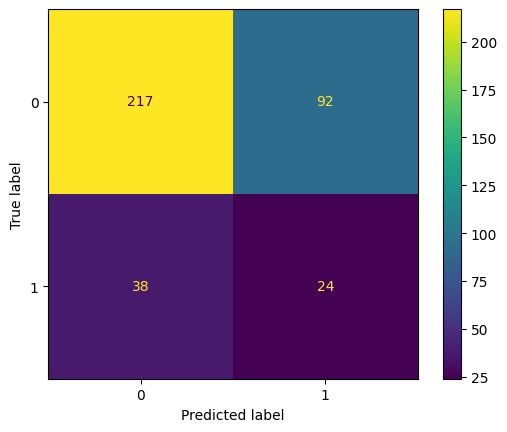

In [131]:
# Matriz de confusion: Test set
print("Matriz de Confusión (Test):")
ConfusionMatrixDisplay.from_predictions(y_test, y_test_predict)

# Árbol de decisión

Ahora vamos a repetir el análisis usando un árbol de decisión.

Este modelo tiene una interpretación diferente al clasificador lineal:

- divide el espacio de atributos mediante reglas;
- puede capturar relaciones no lineales;
- puede sobreajustar si crece demasiado.

Preguntas orientadoras:

1. ¿Qué profundidad alcanza el árbol por defecto?
2. ¿Hay evidencia de sobreajuste?
3. ¿Qué hiperparámetros podemos ajustar?
4. ¿Qué criterio conviene probar: `gini`, `entropy` o `log_loss`?
5. ¿Qué efecto tiene `max_depth`?
6. ¿Qué efecto tiene `min_samples_leaf`?


## Ejercicio 3: Árboles de Decisión

En este ejercicio se entrenarán árboles de decisión para predecir la variable objetivo.

Para ello, deberán utilizar la clase DecisionTreeClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/tree.html
  - https://scikit-learn.org/stable/modules/tree.html#tips-on-practical-use
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html

### Ejercicio 3.1: DecisionTreeClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador DecisionTreeClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


In [132]:
# División entre instancias y etiquetas
X, y = loan_df.iloc[:, 1:], loan_df.TARGET

# Reservo un 20% del dataset para test
X_aux, X_test, y_aux, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

# Del 80% restante, reservo el 20% para validacion
X_train, X_val, y_train, y_val = train_test_split(X_aux, y_aux, test_size=0.2, stratify=y_aux, random_state=0)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_val:", X_val.shape)
print("Tamaño de X_test:", X_test.shape)

Tamaño de X_train: (1186, 10)
Tamaño de X_val: (297, 10)
Tamaño de X_test: (371, 10)


In [133]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [134]:
y_train_predict = clf.predict(X_train)
y_val_predict = clf.predict(X_val)

In [135]:
# Evaluacion de metricas: Train set
print('Best Model Training metrics\n')
print(f'Accuracy : {accuracy_score(y_train, y_train_predict):.4f}')
print(f'Precisiom: {precision_score(y_train, y_train_predict):.4f}')
print(f'Recall   : {recall_score(y_train, y_train_predict):.4f}')
print(f'F1-score : {f1_score(y_train, y_train_predict):.4f}\n')

# Muestro metricas usando classification_report
target_names = ['class 0', 'class 1']
print(classification_report(y_train, y_train_predict, target_names=target_names))

Best Model Training metrics

Accuracy : 1.0000
Precisiom: 1.0000
Recall   : 1.0000
F1-score : 1.0000

              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00       988
     class 1       1.00      1.00      1.00       198

    accuracy                           1.00      1186
   macro avg       1.00      1.00      1.00      1186
weighted avg       1.00      1.00      1.00      1186



Matriz de Confusión (Train):


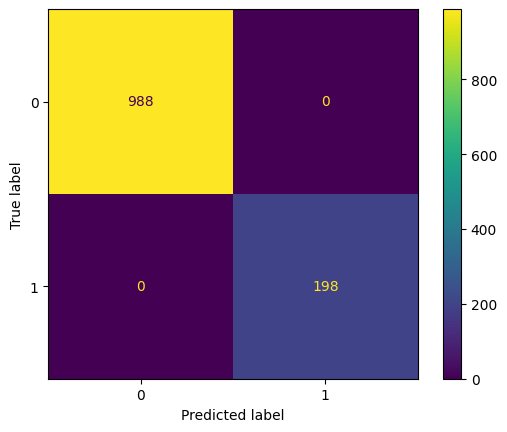

In [136]:
# Matriz de confusion: Train set
print("Matriz de Confusión (Train):")
ConfusionMatrixDisplay.from_predictions(y_train, y_train_predict)

In [137]:
# Evaluacion de metricas: Validation set
print('Best Model Validation metrics\n')
print(f'Accuracy : {accuracy_score(y_val, y_val_predict):.4f}')
print(f'Precisiom: {precision_score(y_val, y_val_predict):.4f}')
print(f'Recall   : {recall_score(y_val, y_val_predict):.4f}')
print(f'F1-score : {f1_score(y_val, y_val_predict):.4f}\n')

# Muestro metricas usando classification_report
target_names = ['class 0', 'class 1']
print(classification_report(y_val, y_val_predict, target_names=target_names))

Best Model Validation metrics

Accuracy : 0.8754
Precisiom: 0.6765
Recall   : 0.4694
F1-score : 0.5542

              precision    recall  f1-score   support

     class 0       0.90      0.96      0.93       248
     class 1       0.68      0.47      0.55        49

    accuracy                           0.88       297
   macro avg       0.79      0.71      0.74       297
weighted avg       0.86      0.88      0.87       297



Matriz de Confusión (Validation):


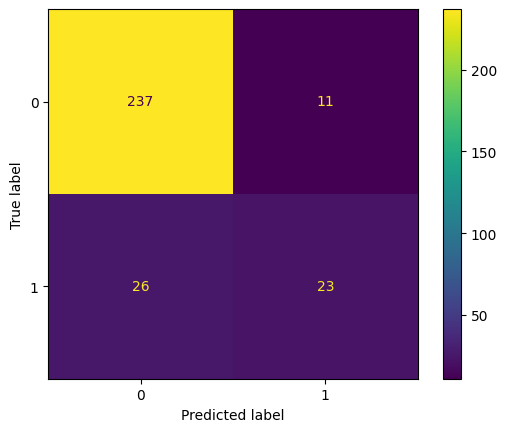

In [138]:
# Matriz de confusion: Train set
print("Matriz de Confusión (Validation):")
ConfusionMatrixDisplay.from_predictions(y_val, y_val_predict)

### Ejercicio 3.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del DecisionTreeClassifier. Como mínimo, probar diferentes criterios de partición (criterion), profundidad máxima del árbol (max_depth), y cantidad mínima de samples por hoja (min_samples_leaf).

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [139]:
# División entre instancias y etiquetas
X, y = loan_df.iloc[:, 1:], loan_df.TARGET

# Reservo un 20% del dataset para test
X_train, X_test, y_train, y_test = train_test_split(X, y,
                  test_size=0.2, stratify=y, random_state=0)

In [140]:
model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [2, 4, 8, 16, 32, 64, 128],
    'min_samples_split': [1, 2, 4],
    'min_samples_leaf': [1, 2, 4]
}

# Definir la estrategia Stratified k-fold cross-validation
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Ejecucion de busqueda de hiperparametros
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=stratified_kfold,
    scoring=[
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro"
    ],
    refit="f1_macro",
    return_train_score=True,
    n_jobs=-1
)

# Ajuste/exploracion via CV
grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [2, 4, 8, 16, 32, 64, 128],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [1, 2, 4]},
             refit='f1_macro', return_train_score=True,
             scoring=['accuracy', 'precision_macro', 'recall_macro',
                      'f1_macro'])

In [141]:
# Impresión de mejores valores directos
print(f"Mejor combinación de hiperparámetros (best_params_): {grid_search.best_params_}")
print(f"Mejor score promedio en CV (best_score_): {grid_search.best_score_:.4f}\n")

Mejor combinación de hiperparámetros (best_params_): {'criterion': 'entropy', 'max_depth': 32, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor score promedio en CV (best_score_): 0.7329



In [142]:
# Convertir todo el diccionario de resultados a DataFrame
df_resultados = pd.DataFrame(grid_search.cv_results_)

# Calcular la VARIANZA a partir de la desviación estándar (std**2)
df_resultados['variance_test_accuracy'] = df_resultados['std_test_accuracy']**2

# Definir las columnas básicas de parámetros y resumen que ya teníamos
columnas_base = [
    'param_criterion',
    'param_max_depth',
    'param_min_samples_leaf',
    'param_min_samples_split',
    'mean_train_f1_macro',     # Desempeño promedio en entrenamiento
    'mean_test_f1_macro',      # Desempeño promedio en validación (Test de CV)
    'std_test_f1_macro',       # Variabilidad entre folds para F1
    'mean_test_accuracy',      # Exactitud Promedio
    'variance_test_accuracy'   # Varianza de la Exactitud
]

tabla_detallada = df_resultados[columnas_base].sort_values(
    by='mean_test_f1_macro',
    ascending=False
)

tabla_detallada.columns = [
    'Criteriom', 'Max Depth', 'Min Samples Leaf', 'Min Samples Split',
    'F1 Train Promedio', 'F1 Validación Promedio', 'Std F1 Validación',
    'Accuracy Promedio', 'Varianza Accuracy'
]

# Mostramos el Top 5 de combinaciones
tabla_detallada.head(5)

,Criteriom,Max Depth,Min Samples Leaf,Min Samples Split,F1 Train Promedio,F1 Validación Promedio,Std F1 Validación,Accuracy Promedio,Varianza Accuracy
181,log_loss,128,1,2,1.0,0.732899,0.02287,0.859732,0.00016
172,log_loss,64,1,2,1.0,0.732899,0.02287,0.859732,0.00016
163,log_loss,32,1,2,1.0,0.732899,0.02287,0.859732,0.00016
118,entropy,128,1,2,1.0,0.732899,0.02287,0.859732,0.00016
109,entropy,64,1,2,1.0,0.732899,0.02287,0.859732,0.00016


In [143]:
# Como gridsearch ya tiene seleccionado el mejor modelo, evaluo los conjuntos de
# entrenamiento y validacion sobre gridsearch directamente
model = grid_search.best_estimator_

y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)

Best Model Training metrics

Accuracy : 1.0000
Precisiom: 1.0000
Recall   : 1.0000
F1-score : 1.0000

              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00      1236
     class 1       1.00      1.00      1.00       247

    accuracy                           1.00      1483
   macro avg       1.00      1.00      1.00      1483
weighted avg       1.00      1.00      1.00      1483

Matriz de Confusión (Train):


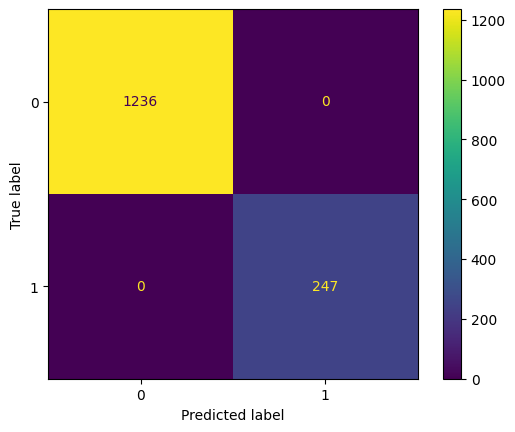

In [144]:
# Evaluacion de metricas: Train set
print('Best Model Training metrics\n')
print(f'Accuracy : {accuracy_score(y_train, y_train_predict):.4f}')
print(f'Precisiom: {precision_score(y_train, y_train_predict):.4f}')
print(f'Recall   : {recall_score(y_train, y_train_predict):.4f}')
print(f'F1-score : {f1_score(y_train, y_train_predict):.4f}\n')

# Muestro metricas usando classification_report
target_names = ['class 0', 'class 1']
print(classification_report(y_train, y_train_predict, target_names=target_names))

# Matriz de confusion: Train set
print("Matriz de Confusión (Train):")
ConfusionMatrixDisplay.from_predictions(y_train, y_train_predict)

Best Model Test metrics

Accuracy : 0.8760
Precisiom: 0.6481
Recall   : 0.5645
F1-score : 0.6034

              precision    recall  f1-score   support

     class 0       0.91      0.94      0.93       309
     class 1       0.65      0.56      0.60        62

    accuracy                           0.88       371
   macro avg       0.78      0.75      0.76       371
weighted avg       0.87      0.88      0.87       371

Matriz de Confusión (Test):


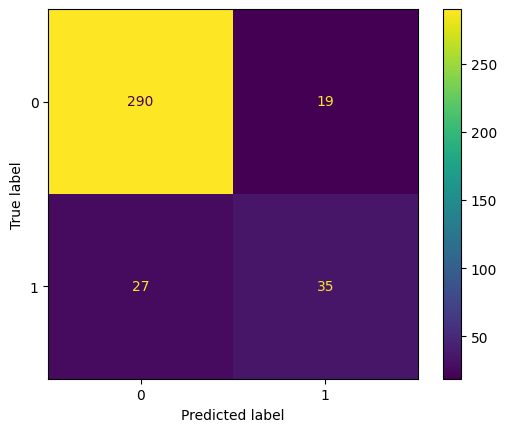

In [145]:
# Evaluacion de metricas: Test set
print('Best Model Test metrics\n')
print(f'Accuracy : {accuracy_score(y_test, y_test_predict):.4f}')
print(f'Precisiom: {precision_score(y_test, y_test_predict):.4f}')
print(f'Recall   : {recall_score(y_test, y_test_predict):.4f}')
print(f'F1-score : {f1_score(y_test, y_test_predict):.4f}\n')

# Muestro metricas usando classification_report
target_names = ['class 0', 'class 1']
print(classification_report(y_test, y_test_predict, target_names=target_names))

# Matriz de confusion: Test set
print("Matriz de Confusión (Test):")
ConfusionMatrixDisplay.from_predictions(y_test, y_test_predict)

# Conclusión final del trabajo práctico

Para cerrar el TP, escribamos una conclusión breve respondiendo:

1. ¿Cuál fue el mejor modelo encontrado?

Rta.: El DecisionTreeClassifier con 5-kfold cv fue ampliamente superior al resto de modelos.

2. ¿Con qué hiperparámetros?

Rta.: {'criterion': 'entropy', 'max_depth': 32, 'min_samples_leaf': 1, 'min_samples_split': 2}


3. ¿Qué métrica usamos para decidir?

Rta.: F1-Score

4. ¿Por qué esa métrica es adecuada para este problema?

Rta.: Busca un buen desempeño equilibrado en la clasificación de ambas clases. En este caso queremos que el banco facilite créditos a sus clientes para hacer girar la rueda de la economía siempre y cuando el perfil del cliente permita predecir una cancelación de la deuda en regla.

5. ¿El modelo parece estable entre folds?

Rta.: Debo hacer una separación entre folds para responder esta pregunta.

6. ¿Hay señales de sobreajuste?

Rta.: Al usar DecisionTreeClassifier las metricas asociadas al conjunto de entrenamiento son perfectas, mientras que al implementar el modelo en el conjunto de validación/testeo el rendimiento cae notablemente. Esto es una clara señal de sobreajuste y ocurre tanto con la optimización de hiperparámetros como con sus valores default.

7. ¿Qué tipo de error nos preocupa más: falso positivo o falso negativo?

Rta.: Es más crítico para el banco un falso negativo, ya que un perfil se clasifica como cumplidor cuando no saldó la deuda a tiempo.

8. ¿Recomendaríamos usar este modelo en un contexto real? ¿Qué advertencias haríamos?

Rta.: Teniendo un f1-score menor a 0.85 no recomendaría usar este modelo en un entorno real. Sobre todo cuando es deficiente para identificar riesgos de cancelación de deuda como en este caso.


# Sugerencia opcional: tabla comparativa final

Podemos resumir los resultados en una tabla como esta:

| Modelo | Mejor configuración | Accuracy test | Precision | Recall | F1 | Comentario |
|---|---|---:|---:|---:|---:|---|
| SGDClassifier | ... | ... | ... | ... | ... | ... |
| DecisionTreeClassifier | ... | ... | ... | ... | ... | ... |

Esta tabla ayuda a comparar modelos de manera ordenada.
